In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('customer_purchase_data.csv', index_col=0)
data.head()

,session_duration_sec,pages_viewed,bounce,device_type,traffic_source,is_new_visitor,avg_time_per_page_sec,purchase
session_id,,,,,,,,
1,120,5,0,desktop,organic,1,24.00,0
2,340,12,0,mobile,paid,0,28.33,1
3,45,1,1,mobile,social,1,NaN,0
4,890,22,0,desktop,direct,0,40.45,1
5,67,2,0,tablet,email,1,33.50,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 100
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   session_duration_sec   100 non-null    int64  
 1   pages_viewed           100 non-null    int64  
 2   bounce                 100 non-null    int64  
 3   device_type            100 non-null    object 
 4   traffic_source         100 non-null    object 
 5   is_new_visitor         100 non-null    int64  
 6   avg_time_per_page_sec  87 non-null     float64
 7   purchase               100 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 7.0+ KB


In [4]:
data.isnull().sum()

,0
session_duration_sec,0
pages_viewed,0
bounce,0
device_type,0
traffic_source,0
is_new_visitor,0
avg_time_per_page_sec,13
purchase,0


In [5]:
data['avg_time_per_page_sec'] = data['avg_time_per_page_sec'].fillna(data["session_duration_sec"]/data["pages_viewed"])
data.head()

,session_duration_sec,pages_viewed,bounce,device_type,traffic_source,is_new_visitor,avg_time_per_page_sec,purchase
session_id,,,,,,,,
1,120,5,0,desktop,organic,1,24.00,0
2,340,12,0,mobile,paid,0,28.33,1
3,45,1,1,mobile,social,1,45.00,0
4,890,22,0,desktop,direct,0,40.45,1
5,67,2,0,tablet,email,1,33.50,0


In [6]:
data ["bounce"] = np.where(data["pages_viewed"] == 1,1,0)
data.iloc[25]

,26
session_duration_sec,67
pages_viewed,2
bounce,0
device_type,mobile
traffic_source,paid
is_new_visitor,1
avg_time_per_page_sec,33.5
purchase,0


In [7]:
data.isnull().sum()

,0
session_duration_sec,0
pages_viewed,0
bounce,0
device_type,0
traffic_source,0
is_new_visitor,0
avg_time_per_page_sec,0
purchase,0


In [8]:
data = pd.get_dummies(data, columns=["device_type","traffic_source"], drop_first=True)
data.head()

,session_duration_sec,pages_viewed,bounce,is_new_visitor,avg_time_per_page_sec,purchase,device_type_mobile,device_type_tablet,traffic_source_email,traffic_source_organic,traffic_source_paid,traffic_source_social
session_id,,,,,,,,,,,,
1,120,5,0,1,24.00,0,False,False,False,True,False,False
2,340,12,0,0,28.33,1,True,False,False,False,True,False
3,45,1,1,1,45.00,0,True,False,False,False,False,True
4,890,22,0,0,40.45,1,False,False,False,False,False,False
5,67,2,0,1,33.50,0,False,True,True,False,False,False


In [9]:
x = data.drop("purchase",axis =1)
y = data["purchase"]

In [10]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)

In [11]:
x_train.head()

,session_duration_sec,pages_viewed,bounce,is_new_visitor,avg_time_per_page_sec,device_type_mobile,device_type_tablet,traffic_source_email,traffic_source_organic,traffic_source_paid,traffic_source_social
session_id,,,,,,,,,,,
56,689,21,0,0,32.81,False,False,True,False,False,False
89,73,3,0,1,24.33,False,False,False,False,False,True
27,389,12,0,1,32.42,False,True,False,False,False,False
43,378,13,0,0,29.08,True,False,False,False,False,False
70,768,24,0,0,32.00,False,False,False,True,False,False


In [12]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 84 to 32
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_duration_sec    20 non-null     int64  
 1   pages_viewed            20 non-null     int64  
 2   bounce                  20 non-null     int64  
 3   is_new_visitor          20 non-null     int64  
 4   avg_time_per_page_sec   20 non-null     float64
 5   device_type_mobile      20 non-null     bool   
 6   device_type_tablet      20 non-null     bool   
 7   traffic_source_email    20 non-null     bool   
 8   traffic_source_organic  20 non-null     bool   
 9   traffic_source_paid     20 non-null     bool   
 10  traffic_source_social   20 non-null     bool   
dtypes: bool(6), float64(1), int64(4)
memory usage: 1.1 KB


In [13]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 80 entries, 56 to 52
Series name: purchase
Non-Null Count  Dtype
--------------  -----
80 non-null     int64
dtypes: int64(1)
memory usage: 1.2 KB


In [14]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 20 entries, 84 to 32
Series name: purchase
Non-Null Count  Dtype
--------------  -----
20 non-null     int64
dtypes: int64(1)
memory usage: 320.0 bytes


In [15]:
x_train.shape

(80, 11)

In [16]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

#ANN Model

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(Dense(16,activation="relu", input_dim = x_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(8,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

## Using Adam optimizer

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
model.compile(optimizer="adam",loss = "binary_crossentropy",metrics=["accuracy"])

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

earlystopping = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

In [21]:
history = model.fit(x_train,y_train,epochs=50,batch_size=32,validation_split=0.2,callbacks=[earlystopping])

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - accuracy: 0.4531 - loss: 0.8748 - val_accuracy: 0.5000 - val_loss: 0.7294
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.5156 - loss: 0.7878 - val_accuracy: 0.5000 - val_loss: 0.7191
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.6562 - loss: 0.7218 - val_accuracy: 0.5000 - val_loss: 0.7095
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4688 - loss: 0.7708 - val_accuracy: 0.5000 - val_loss: 0.7001
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6094 - loss: 0.7305 - val_accuracy: 0.5000 - val_loss: 0.6912
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5469 - loss: 0.6718 - val_accuracy: 0.5625 - val_loss: 0.6827
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5469 - loss: 0.6778 - val_accuracy: 0.5625 - val_loss: 0.6745
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5469 - loss: 0.6825 - val_accuracy: 0.6250 - val_loss: 

In [22]:
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Accuracy: 0.75
Precision: 1.0
Recall: 0.375
F1 Score: 0.5454545454545454


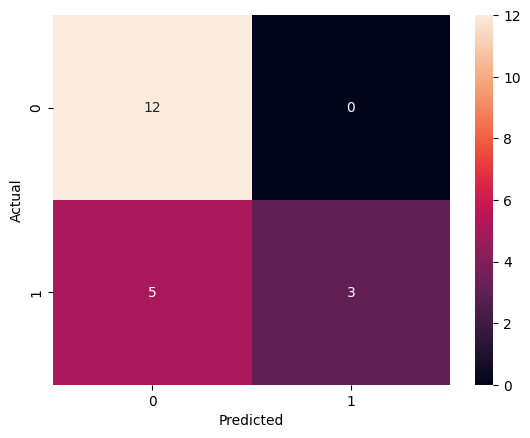

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##SGD Optimizer

In [24]:
model_sgd = Sequential()

model_sgd.add(Dense(16, activation='relu', input_dim=x_train.shape[1]))
model.add(Dropout(0.3))
model_sgd.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))
model_sgd.add(Dense(1, activation='sigmoid'))

model_sgd.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])

history_sgd = model_sgd.fit(x_train, y_train,epochs=50,batch_size=32,validation_split=0.2,callbacks=[earlystopping])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.3906 - loss: 0.7733 - val_accuracy: 0.4375 - val_loss: 0.8427
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4062 - loss: 0.7655 - val_accuracy: 0.4375 - val_loss: 0.8363
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4219 - loss: 0.7578 - val_accuracy: 0.5000 - val_loss: 0.8301
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4375 - loss: 0.7502 - val_accuracy: 0.5000 - val_loss: 0.8243
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4375 - loss: 0.7429 - val_accuracy: 0.5000 - val_loss: 0.8187


In [25]:
y_pred_sgd = model.predict(x_test)
y_pred_sgd = (y_pred_sgd > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_sgd))
print("Precision:", precision_score(y_test, y_pred_sgd))
print("Recall:", recall_score(y_test, y_pred_sgd))
print("F1 Score:", f1_score(y_test, y_pred_sgd))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Accuracy: 0.75
Precision: 1.0
Recall: 0.375
F1 Score: 0.5454545454545454


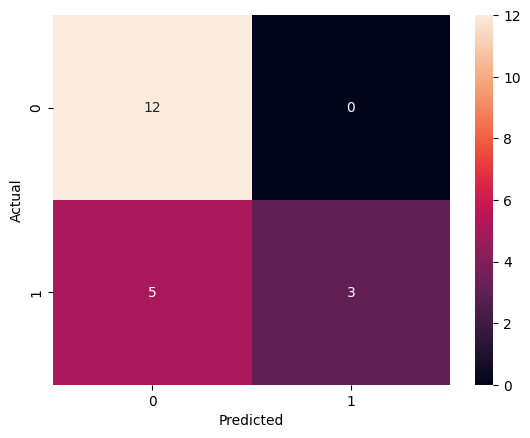

In [26]:
cm_sgd = confusion_matrix(y_test,y_pred_sgd)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

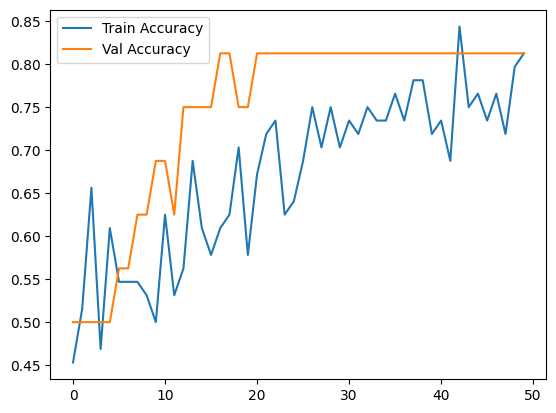

In [27]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()